# PD-Weighted 3D-CUBE Locus Coeruleus Analysis Pipeline (7T)

In [1]:
# TUS 
# Steps:
# 1. inverse registration of MNI space to native space 
# 2. within-subject registration of PD(proton-density weighted) 3D-CUBE data to T1
# 3. apply baseline threshold to identify LC in 3D-CUBE data 
# Inputs:
# -T1 in 7T
# -PD 3D-CUBE
# -LC probability map
# 
# Last update:
# - waiting for LC prob map
# ====================================================================================================================
%reset -f

# Load modules/packages
from basic_python import * # now added to startup folder
from mri_python import *
globals().update(configure_mri_env())

# Basic
import cv2 #  Open Source Computer Vision Library
import scipy.io
import scipy.ndimage as ndi
from scipy.ndimage import center_of_mass
import matplotlib.pyplot as plt

# Nipype
import nibabel as nib
from nipype.interfaces.spm import NewSegment
from nipype.interfaces.matlab import MatlabCommand
from nibabel.orientations import io_orientation, axcodes2ornt, ornt_transform, apply_orientation
os.environ["NILEARN_DATA"] = "/Users/atsushikikumoto/Dropbox/w_ONGOINGANY/atlases"

# Nilearn
from nilearn import datasets, image, masking, plotting
from nilearn.image import math_img, resample_to_img, new_img_like

# Ants
# https://github.com/ANTsX/ANTs?tab=readme-ov-file
# https://github.com/antsx/antspy
import ants

# MNI space/LC probability map templates
from templateflow.api import get
t1_mni_path = get('MNI152NLin2009cAsym', resolution=1, suffix='T1w', extension='nii.gz')
t1_mni = ants.image_read(str([p for p in t1_mni_path if 'desc-brain' not in str(p)][0]))
t1_mni_brain = ants.image_read(str([p for p in t1_mni_path if 'desc-brain' in str(p)][0]))

# Define paths 
DIR_HERE = Path(os.path.dirname(os.path.realpath("__file__")))
DIR_DATA = Path(DIR_HERE).parents[0] / "PilotData" / "LCScan_Pilot" / "7T"
# DIR_DATA = Path.home() / "Dropbox (Personal)" / "w_SCRIPTS" / "P.TUSPractice" / "SUB_LIST_PREP" 
DIR_MASK_TMP = DIR_HERE / 'z_masks_templates'
DIR_MASK_OUT = DIR_HERE / 'z_masks_outputs'

# Files
DIR_3DCUBEFILES = list(DIR_DATA.rglob('sub-*melanin1.nii'))
DIR_T1FILES = list(DIR_DATA.rglob('sub-*_T1w_7T.nii'))
SUBJECT_ID = [f.stem.split("_")[0] for f in DIR_T1FILES]

# Files (LC related)
DIR_LCMASK = DIR_MASK_TMP / "Dahl_LCmax_prob_MNI05.nii.gz"
DIR_BSMASK = DIR_MASK_TMP / "Neuromorphometrics_BrainStem_mask_1mm.nii"

%whos

Variable                       Type         Data/Info
-----------------------------------------------------
Counter                        type         <class 'collections.Counter'>
DIR_3DCUBEFILES                list         n=5
DIR_BSMASK                     PosixPath    /Users/atsushikikumoto/Dr<...>cs_BrainStem_mask_1mm.nii
DIR_DATA                       PosixPath    /Users/atsushikikumoto/Dr<...>PilotData/LCScan_Pilot/7T
DIR_HERE                       PosixPath    /Users/atsushikikumoto/Dr<...>/TUS_LSRDM/TUS_simulation
DIR_LCMASK                     PosixPath    /Users/atsushikikumoto/Dr<...>l_LCmax_prob_MNI05.nii.gz
DIR_MAIN                       PosixPath    /Users/atsushikikumoto/Dr<...>pbox (Personal)/w_SCRIPTS
DIR_MASK_OUT                   PosixPath    /Users/atsushikikumoto/Dr<...>imulation/z_masks_outputs
DIR_MASK_TMP                   PosixPath    /Users/atsushikikumoto/Dr<...>ulation/z_masks_templates
DIR_SPM                        PosixPath    /Users/atsushikikumoto/Dr<

In [5]:
# # -------------
# Checking: pons
# # -------------

# Read both with consistent orientation and affine
bs_mask_ants = ants.image_read(str(DIR_BSMASK))  # ANTs
# bs_mask_ras = ants.reorient_image2(bs_mask_ants, 'RAS')

# Convert to Nibabel with correct affine
bs_mask_nib = ants_to_nib(bs_mask_ants)

# Now plot
plotting.view_img(
    stat_map_img=bs_mask_nib,
    #bg_img=ants_to_nib(ants.reorient_image2(t1_mni, 'RAS')),  # also reorient background
    bg_img=ants_to_nib(ants.reorient_image2(t1_mni, 'RAS')),  # also reorient background
    cmap='Reds',
    threshold=0.1,
    title='Brainstem Mask (Aligned RAS)'
).open_in_browser()


/Users/atsushikikumoto/opt/anaconda3/envs/mri/lib/python3.10/site-packages/numpy/core/fromnumeric.py:771: UserWarning:


/var/folders/st/vdmcwrln1mb0m0p2cbhwfhvc0000gn/T/ipykernel_69910/2846731566.py:13: UserWarning:

Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.



In [77]:
# Define mask file (in MNI space) --------------------------------
sub_id = DIR_T1FILES[sub_idx].stem.split("_")[0]
lcmask_mni = ants.image_read(str(DIR_LCMASK))
bs_mask_mni = ants.image_read(str(DIR_BSMASK))

# Define reference mask in MNI space (using Neuromorphometrics_BrainStem_mask_1mm)
# -original used labels_Neuromorphometrics.nii z-threshold=100 for pons
bs_mask_np = bs_mask_mni.numpy()
bs_mask_np_zrange = bs_mask_mni.origin[2] + np.arange(bs_mask_np.shape[2]) * bs_mask_mni.spacing[2]

# Define anatomical Z cutoff in mm (e.g., exclude midbrain)
z_cutoff = -24
truncated_bs_np = bs_mask_np.copy()
truncated_bs_np[:, :, ~(bs_mask_np_zrange < z_cutoff)] = 0

plt.plot(truncated_bs_np.sum(axis=(0, 1)))
plt.title("Truncated Brainstem (MNI) voxel count per Z")

NameError: name 'sub_idx' is not defined

In [3]:
# # -------------
# Step1: 
# Inverse registration (MNI -> native)
# register MNI T1 template to subject-specific T1 data
# In ANTs, fwdtransforms actually maps moving → fixed 
# -save transformation and apply to LC map, brain stem and reference (baseline)
# # -------------

# Define mask file ------------------------------------------
sourceIM = 'T1w_7T'
filenames = [p.name for p in  DIR_T1FILES]
sub_idx = filenames.index(f"sub-M3827_{sourceIM}.nii")
sub_id = DIR_T1FILES[sub_idx].stem.split("_")[0]
print("subject", sub_id)

# Load subject specific files
lcmask_mni = ants.image_read(str(DIR_LCMASK))
bs_mask_mni = ants.image_read(str(DIR_BSMASK))
t1_native = load_as_3d(str(DIR_T1FILES[sub_idx]))

# Count number of LC voxels in template 
lc_bin = (lcmask_mni.numpy() > 0.05).astype(np.uint8)
n_bin_voxels = np.count_nonzero(lc_bin)
print(f"Original LC voxels (thresholded > 0.05): {n_bin_voxels}")

# Define reference mask in MNI space (using Neuromorphometrics_BrainStem_mask_1mm)
# -original used labels_Neuromorphometrics.nii z-threshold=100 for pons
bs_mask_np = bs_mask_mni.numpy()
bs_mask_np_zrange = bs_mask_mni.origin[2] + np.arange(bs_mask_np.shape[2]) * bs_mask_mni.spacing[2]

# Define anatomical Z cutoff in mm (e.g., exclude midbrain)
z_cutoff = -24
truncated_bs_np = bs_mask_np.copy()
truncated_bs_np[:, :, ~(bs_mask_np_zrange < z_cutoff)] = 0
# plt.plot(truncated_bs_np.sum(axis=(0, 1)))
# plt.title("Truncated Brainstem (MNI) voxel count per Z (in MNI space)")

ref_mask_mni = ants.from_numpy(
    truncated_bs_np.astype(np.float32),
    origin=bs_mask_mni.origin,
    spacing=bs_mask_mni.spacing,
    direction=bs_mask_mni.direction
)

# Reorient subject native T1 to RAS (for registration) -------
# always use original T1 data for neuronavigation
t1_native_ras = ants.reorient_image2(t1_native, orientation='RAS')

# Upsample t1 data
# t1_native_ras = ants.resample_image(t1_native_ras, (0.5, 0.5, 0.5), use_voxels=False)

# Histogram-match MNI template to native T1

# # Otpion1: using histogram_match_image
# t1_mni_hm = ants.histogram_match_image(
#     source_image=t1_mni,
#     reference_image=t1_native_ras,
#     number_of_histogram_bins=256,
#     number_of_match_points=128, 
#     use_threshold_at_mean_intensity=True
#     )

# # Option2: ants.iMath
t1_mni_hm = ants.iMath(t1_mni, "Normalize")  # mild normalization

# Option 3: do nothing
# t1_mni_hm = t1_mni

# MNI T1 → subject native T1
# Step 1: Affine registration
reg_affine = ants.registration(
    fixed=t1_native_ras,
    moving=t1_mni_hm,
    type_of_transform='Affine'
)

# MNI T1 → subject native T1
# Step 2: SyNCC registration initialized with affine transform
reg_sub_mni = ants.registration(
    fixed=t1_native_ras,
    moving=t1_mni_hm,
    type_of_transform='SyNCC',
    initial_transform=reg_affine['fwdtransforms'][0]  # affine.xfm
)


# Transform LC mask into native space (RAS-oriented) -----------
lc_mask_native_ras = ants.apply_transforms(
    fixed=t1_native_ras, 
    moving=lcmask_mni, 
    transformlist=reg_sub_mni['fwdtransforms'],  # use forward transform
    interpolator='gaussian'  # try 'linear','gaussian' or 'bspline' as well
)

# Count number of LC voxels in transformed space 
lc_bin = (lc_mask_native_ras.numpy() > 0.05).astype(np.uint8)
n_bin_voxels = np.count_nonzero(lc_bin)
print(f"after transform LC voxels (thresholded > 0.05): {n_bin_voxels}")

# Transform brainstem mask into native space (RAS-oriented)
bs_mask_native_ras = ants.apply_transforms(
    fixed=t1_native_ras, 
    moving=bs_mask_mni, 
    transformlist=reg_sub_mni['fwdtransforms'],  
    interpolator='nearestNeighbor'
)

# Transform reference mask into native space (RAS-oriented)
ref_mask_native_ras = ants.apply_transforms(
    fixed=t1_native_ras,
    moving=ref_mask_mni,
    transformlist=reg_sub_mni['fwdtransforms'],
    interpolator='nearestNeighbor'
)

# Confine masks to be within brains 
brain_mask_native = ants.get_mask(t1_native_ras)
lc_mask_native_ras *= brain_mask_native
bs_mask_native_ras *= brain_mask_native
ref_mask_native_ras *= brain_mask_native

# !!!!!!!!!! COUNTING LC !!!!!!!!!!!!!!
lc_bin = (lc_mask_native_ras.numpy() > 0.05).astype(np.uint8)
n_bin_voxels = np.count_nonzero(lc_bin)
print(f"after masking LC voxels (thresholded > 0.05): {n_bin_voxels}")


# Resample warped mask to match original T1 orientation
lc_mask_native = ants.resample_image_to_target(lc_mask_native_ras, t1_native)
bs_mask_native = ants.resample_image_to_target(bs_mask_native_ras, t1_native)
ref_mask_native = ants.resample_image_to_target(ref_mask_native_ras, t1_native)

# !!!!!!!!!! COUNTING LC !!!!!!!!!!!!!!
lc_bin = (lc_mask_native.numpy() > 0.05).astype(np.uint8)
n_bin_voxels = np.count_nonzero(lc_bin)
print(f"after resampling LC voxels (thresholded > 0.05): {n_bin_voxels}")

# Output
ants.image_write(lc_mask_native, str(DIR_T1FILES[sub_idx].parent / f"{sub_id}_LC_mask_native.nii.gz"))
ants.image_write(bs_mask_native, str(DIR_T1FILES[sub_idx].parent / f"{sub_id}_BS_mask_native.nii.gz"))
ants.image_write(ref_mask_native, str(DIR_T1FILES[sub_idx].parent / f"{sub_id}_Ref_fmask_native.nii.gz"))

subject sub-M3827
Original LC voxels (thresholded > 0.05): 175
after transform LC voxels (thresholded > 0.05): 84
after masking LC voxels (thresholded > 0.05): 84
after resampling LC voxels (thresholded > 0.05): 84


In [9]:
# ================================
# Split LC native mask into L / R
# NOTE: Brainstem cannot be labeled to be left or right by atlas
# it will be using midline separation 
# ================================
# Requires:
#   - lc_mask_native_ras (ANTsImage, native RAS space)
#   - t1_native, t1_native_ras
#   - brain_mask_native
#   - reg_sub_mni (MNI -> native registration dict)
#   - filename, DIR_T1FILES, sub_idx
#   - BN atlas + LUT in MNI space  (まずは試すが、ダメなら midline に fallback)
import os
import numpy as np
from pathlib import Path

# --------------------------------
# 1. Load BN atlas and LUT in MNI
# --------------------------------
BN_ROOT = Path(os.getenv("NILEARN_DATA")) / "bn"

bn_atlas_mni = ants.image_read(str(BN_ROOT / "BN_Atlas_246_1mm.nii.gz"))
bn_lut = np.loadtxt(str(BN_ROOT / "BN_Atlas_246_LUT.txt"), dtype=str)

# First column = index, second = label name
bn_ids   = bn_lut[:, 0].astype(int)
bn_names = bn_lut[:, 1].tolist()

left_ids  = [int(idx) for idx, name in zip(bn_ids, bn_names) if name.endswith("_L")]
right_ids = [int(idx) for idx, name in zip(bn_ids, bn_names) if name.endswith("_R")]

print(f"BN atlas left labels:  {len(left_ids)}")
print(f"BN atlas right labels: {len(right_ids)}")

# --------------------------------
# 2. Warp BN atlas to native RAS
# --------------------------------
bn_native_ras = ants.apply_transforms(
    fixed=t1_native_ras,
    moving=bn_atlas_mni,
    transformlist=reg_sub_mni['fwdtransforms'],
    interpolator='nearestNeighbor'
)

bn_np  = bn_native_ras.numpy().astype(int)
lc_np  = lc_mask_native_ras.numpy()
bm_ras = brain_mask_native.numpy()

# --------------------------------
# 3. Try BN-based hemispheres
# --------------------------------
hemi_L_bn = np.isin(bn_np, left_ids)
hemi_R_bn = np.isin(bn_np, right_ids)

mask_L_ras = lc_np * hemi_L_bn
mask_R_ras = lc_np * hemi_R_bn

print("Non-zero voxels (RAS) with BN split:")
print("  Left mask :", np.count_nonzero(mask_L_ras))
print("  Right mask:", np.count_nonzero(mask_R_ras))

# --------------------------------
# 3b. Fallback: midline-based split if BN gives nothing
# --------------------------------
if np.count_nonzero(mask_L_ras) == 0 and np.count_nonzero(mask_R_ras) == 0:
    print("[INFO] BN atlas did not split LC → using midline-based split.")

    # brain mask から midline を推定
    xs = np.where(bm_ras.sum(axis=(1, 2)) > 0)[0]
    x_min, x_max = xs.min(), xs.max()
    mid_x = int(round((x_min + x_max) / 2))
    print(f"[RAS] Brain X-range: {x_min}–{x_max}, mid_x={mid_x}")

    hemi_L_mid = np.zeros_like(lc_np, dtype=bool)
    hemi_R_mid = np.zeros_like(lc_np, dtype=bool)
    hemi_L_mid[:mid_x, :, :] = True
    hemi_R_mid[mid_x:, :, :] = True   # midline 含めて右側に寄せる（好みで変えてOK）

    mask_L_ras = lc_np * hemi_L_mid
    mask_R_ras = lc_np * hemi_R_mid

    print("Non-zero voxels (RAS) with midline split:")
    print("  Left mask :", np.count_nonzero(mask_L_ras))
    print("  Right mask:", np.count_nonzero(mask_R_ras))

# --------------------------------
# 4. Back to ANTs and resample to native T1
# --------------------------------
mask_L_ras_img = ants.from_numpy(
    mask_L_ras.astype(np.float32),
    origin=lc_mask_native_ras.origin,
    spacing=lc_mask_native_ras.spacing,
    direction=lc_mask_native_ras.direction,
)
mask_R_ras_img = ants.from_numpy(
    mask_R_ras.astype(np.float32),
    origin=lc_mask_native_ras.origin,
    spacing=lc_mask_native_ras.spacing,
    direction=lc_mask_native_ras.direction,
)

mask_L = ants.resample_image_to_target(mask_L_ras_img, t1_native)
mask_R = ants.resample_image_to_target(mask_R_ras_img, t1_native)

# --------------------------------
# 5. Save with _L / _R suffix
# --------------------------------
base = f"{sub_id}_LC_mask_native"
out_L = DIR_T1FILES[sub_idx].parent / f"{base}_L.nii.gz"
out_R = DIR_T1FILES[sub_idx].parent / f"{base}_R.nii.gz"

ants.image_write(mask_L, str(out_L))
ants.image_write(mask_R, str(out_R))

print("Saved L/R LC native masks:")
print("  L:", out_L)
print("  R:", out_R)


BN atlas left labels:  123
BN atlas right labels: 123
Non-zero voxels (RAS) with BN split:
  Left mask : 0
  Right mask: 0
[INFO] BN atlas did not split LC → using midline-based split.
[RAS] Brain X-range: 22–188, mid_x=105
Non-zero voxels (RAS) with midline split:
  Left mask : 42
  Right mask: 42
Saved L/R LC native masks:
  L: /Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/161624E863_250718M3827.Shibata_CUBE_250623/sub-M3827_LC_mask_native_L.nii.gz
  R: /Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/161624E863_250718M3827.Shibata_CUBE_250623/sub-M3827_LC_mask_native_R.nii.gz


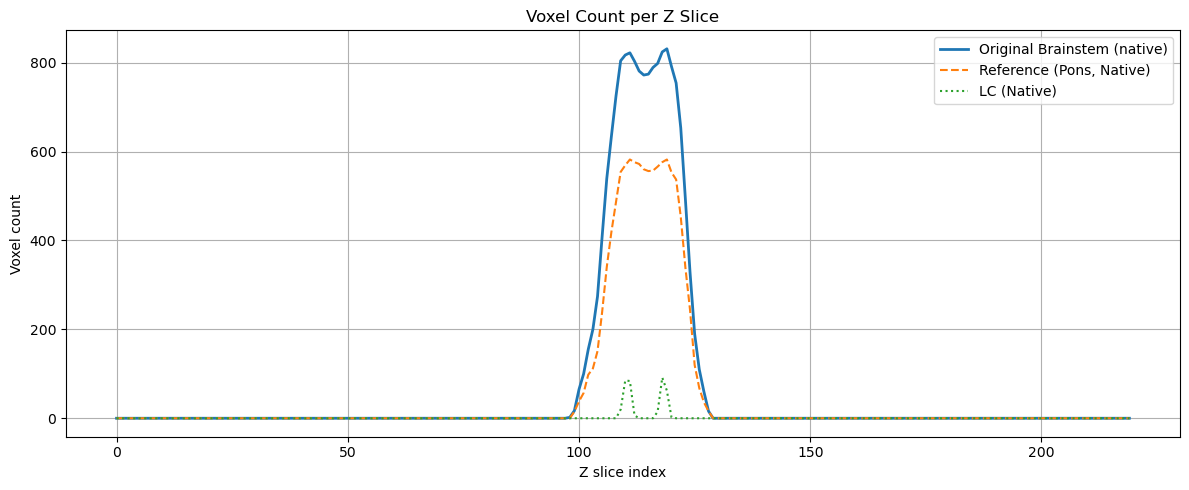

25 overlapping voxels removed from reference mask.


In [5]:
# # -------------
# Step1:
# Checking1: Checking voxel counts
# # -------------

import matplotlib.pyplot as plt

# Convert to numpy arrays
bs_np = bs_mask_native.numpy()
lc_np = lc_mask_native.numpy()
ref_np = ref_mask_native.numpy()

# Count nonzero voxels per Z slice
bs_zcount = bs_np.sum(axis=(0, 1))
lc_zcount = lc_np.sum(axis=(0, 1))
ref_zcount = ref_np.sum(axis=(0, 1))

# Plot
plt.figure(figsize=(12, 5))
plt.plot(bs_zcount, label='Original Brainstem (native)', linewidth=2)
plt.plot(ref_zcount, label='Reference (Pons, Native)', linestyle='--')
plt.plot(lc_zcount, label='LC (Native)', linestyle=':')
plt.title("Voxel Count per Z Slice")
plt.xlabel("Z slice index")
plt.ylabel("Voxel count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Exclude LC from ref_mask_native
ref_mask_cleaned = ref_mask_native.clone()
ref_mask_cleaned[lc_mask_native > 0] = 0

# Sanity check: count how many voxels were excluded
n_excluded = np.sum((ref_mask_native.numpy() > 0) & (lc_mask_native.numpy() > 0))
print(f"{n_excluded} overlapping voxels removed from reference mask.")

/var/folders/st/vdmcwrln1mb0m0p2cbhwfhvc0000gn/T/ipykernel_56221/2746357492.py:25: UserWarning:

kwargs['alpha']=0.2 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.



✅ Overlay figure saved to: /Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/161624E863_250718M3827.Shibata_CUBE_250623/sub-M3827_LC_PONS_native_overlay.png


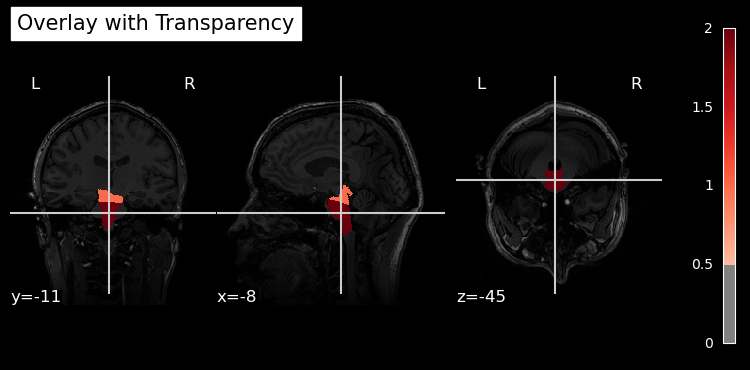

In [7]:
# # -------------
# Step1:
# Checking1: whole brain
# # -------------

# Images to load
t1_native_nib = ants_to_nib(t1_native)
bs_mask_native_nib = ants_to_nib(bs_mask_native)
ref_mask_native_nib = ants_to_nib(ref_mask_native)
lc_mask_native_nib = ants_to_nib(lc_mask_native)

# 1 = Brainstem, 2 = Reference (pons), 3 = LC (will overwrite overlapping voxels)
combined_data = np.zeros(bs_mask_native_nib.shape, dtype=np.uint8)
combined_data[bs_mask_native_nib.get_fdata() > 0] = 1
combined_data[ref_mask_native_nib.get_fdata() > 0] = 2
# combined_data[lc_mask_native_nib.get_fdata() > 0] = 3
combined_mask = nib.Nifti1Image(combined_data, affine=bs_mask_native_nib.affine)


# # Visualize (one at a time)
import webbrowser
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['none', 'deepskyblue', 'red'])  # 0=off, 1=brainstem, 2=pons, 3=LC

fig = plotting.plot_stat_map(
    stat_map_img=combined_mask,
    bg_img=t1_native_nib,
    cmap='Reds',
    threshold=0.5,
    alpha=0.2,
    title="Overlay with Transparency"
)

# Save figure
output_path = DIR_T1FILES[sub_idx].parent / f"{sub_id}_LC_PONS_native_overlay.png"
fig.savefig(output_path, dpi=300)
print(f"✅ Overlay figure saved to: {output_path}")

In [8]:
# # -------------
# Step1:
# Checking1: each masked ROIs
# # -------------
t1_data = t1_native_nib.get_fdata()
t1_data_norm = np.clip((t1_data - np.percentile(t1_data, 1)) / (np.percentile(t1_data, 99) - np.percentile(t1_data, 1)), 0, 1)
t1_bright_nib = nib.Nifti1Image(t1_data_norm, affine=t1_native_nib.affine)

subject_folder = DIR_T1FILES[sub_idx].parent  # Or Path to subject folder
(subject_folder / "figures").mkdir(exist_ok=True)

def plot_and_save(roi_img, bg_img, title, cmap, filename, alpha=0):
    disp = plotting.plot_stat_map(
        stat_map_img=roi_img,
        bg_img=bg_img,
        cmap=cmap,
        alpha=alpha,
        display_mode='z',
        cut_coords=[x -15 for x in [15, 10, 0, -10, -15]],
        threshold=0.01,
        title=title,
        black_bg=False
    )
    save_path = subject_folder / "figures" / filename
    disp.savefig(str(save_path), dpi=150)
    disp.close()

print('subject:', sub_id)
plot_and_save(bs_mask_native_nib, t1_bright_nib, 'Brainstem', 'Blues', f"{sub_id}_BS_mask.png")
plot_and_save(ref_mask_native_nib, t1_bright_nib, 'Pons (Reference)', 'Reds', f"{sub_id}_Pons_mask.png")
plot_and_save(lc_mask_native_nib, t1_bright_nib, 'LC Mask', 'Greens', f"{sub_id}_LC_mask.png")

subject: sub-M3827


/var/folders/st/vdmcwrln1mb0m0p2cbhwfhvc0000gn/T/ipykernel_56221/427409160.py:13: UserWarning:

kwargs['alpha']=0 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.



LC mask center in mm: [ -8.4476438   -3.08922997 -34.99130374]
✅ Overlay figure saved to: /Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/161624E863_250718M3827.Shibata_CUBE_250623/sub-M3827_LC_native_overlay_T1only.png
LC voxels (thr>0.05): L=42, R=42
[RAS] Midline X = 105


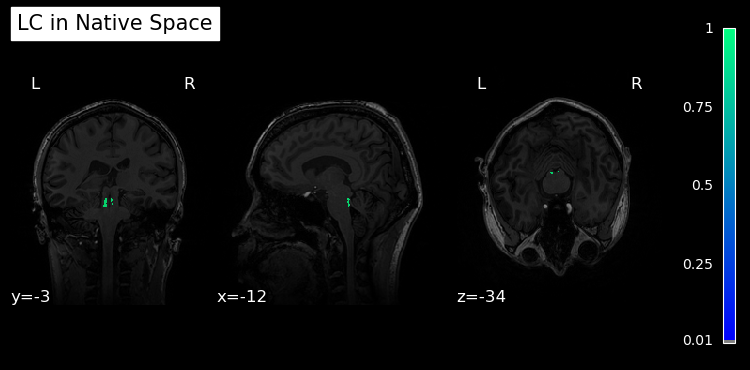

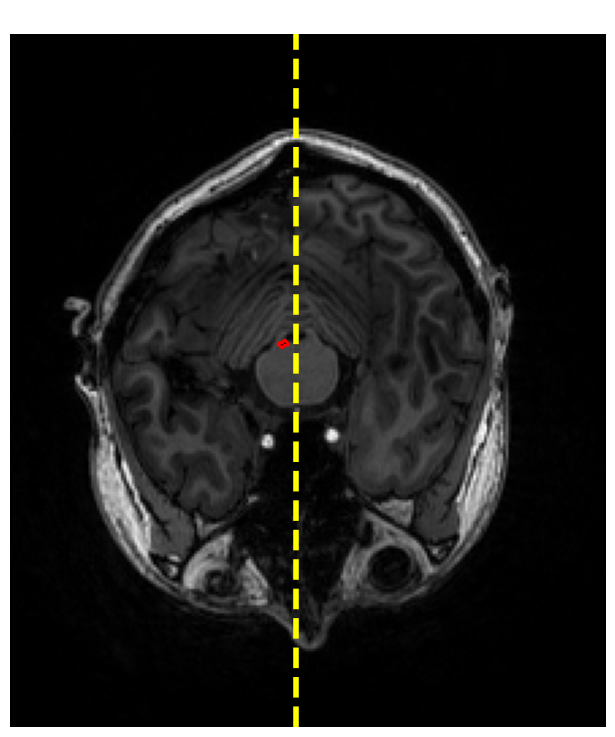

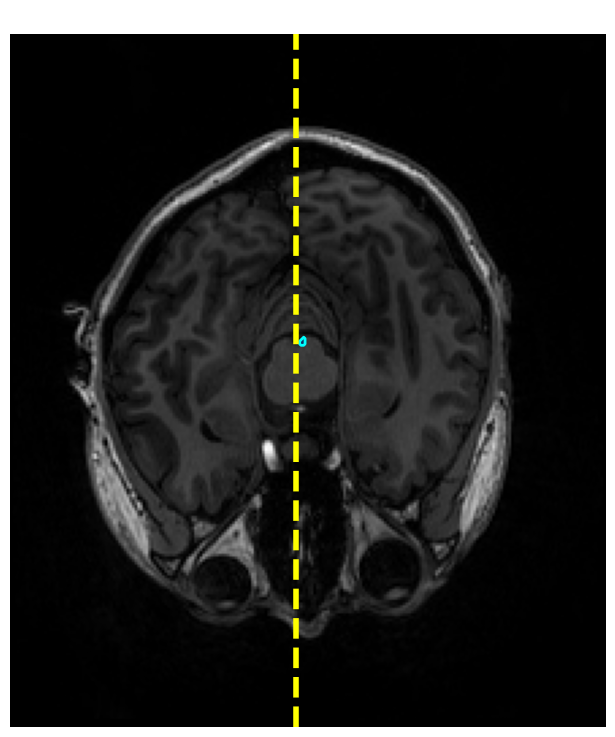

In [15]:
# # -------------
# Step1:
# Checking2: highlighting LC
# # -------------
# Images to load
t1_native_nib = ants_to_nib(t1_native)
bs_mask_native_nib = ants_to_nib(bs_mask_native)
ref_mask_native_nib = ants_to_nib(ref_mask_native)
lc_mask_native_nib = ants_to_nib(lc_mask_native)


# Get data
lc_data = lc_mask_native_nib.get_fdata()
lc_bin_data = (lc_data > 0).astype(np.uint8)
lc_mask_native_binary_nib = nib.Nifti1Image(lc_bin_data, affine=lc_mask_native_nib.affine)

# Get center of mass in voxel coordinates
lc_center_vox = center_of_mass(lc_mask_native.numpy())  # e.g. (x, y, z)

# Extract spacing, origin, and direction
spacing = np.array(lc_mask_native.spacing)    # (sx, sy, sz)
origin = np.array(lc_mask_native.origin)      # (ox, oy, oz)
direction = np.array(lc_mask_native.direction).reshape(3, 3)  # 3x3 matrix

# 3. Convert voxel to physical space
lc_center_mm = direction @ (lc_center_vox * spacing) + origin
print("LC mask center in mm:", lc_center_mm)

# plotting.view_img(
#     stat_map_img=lc_mask_native_binary_nib,
#     bg_img=t1_bright_nib,
#     cmap='Greens',
#     threshold=0.01,
#     symmetric_cmap=False
# ).open_in_browser()


# Plot and save
fig = plotting.plot_stat_map(
    stat_map_img=lc_mask_native_binary_nib,
    bg_img=t1_native_nib,
    threshold=0.01,
    display_mode='ortho',
    cmap='winter',
    transparency = .8,
    draw_cross=False,      # <- no cross lines
    title=f"{'LC'} in Native Space"
)

# Save figure
output_path = DIR_T1FILES[sub_idx].parent / f"{sub_id}_LC_native_overlay_T1only.png"
fig.savefig(output_path, dpi=300)
print(f"✅ Overlay figure saved to: {output_path}")


# ============================
# QA plots for L / R LC masks (BRIGHT + LARGE)
# ============================
import matplotlib.pyplot as plt
import numpy as np

# numpy arrays in RAS
t1_ras = t1_native_ras.numpy()
bm_ras = brain_mask_native.numpy()

L_ras = mask_L_ras
R_ras = mask_R_ras

# threshold （LC強調）
thr = 0.05
L_vis = (L_ras > thr).astype(float)
R_vis = (R_ras > thr).astype(float)

print(f"LC voxels (thr>{thr}): L={int(L_vis.sum())}, R={int(R_vis.sum())}")

# midline from brain mask
xs = np.where(bm_ras.sum(axis=(1, 2)) > 0)[0]
mid_x = int(round((xs.min() + xs.max()) / 2))
print(f"[RAS] Midline X = {mid_x}")

# best slices
z_L = np.argmax(L_vis.sum(axis=(0, 1)))
z_R = np.argmax(R_vis.sum(axis=(0, 1)))

# --------------- PLOT FUNCTION ---------------
def plot_one_bright(z, show_L=True, show_R=True, title=""):
    fig, ax = plt.subplots(figsize=(9, 9))   # 大きく

    # T1
    ax.imshow(t1_ras[:, :, z].T, cmap="gray", origin="lower")

    # LEFT: 明るい赤
    if show_L and L_vis[:, :, z].any():
        ax.imshow(
            np.ma.masked_where(L_vis[:, :, z] == 0, L_vis[:, :, z]).T,
            cmap=plt.cm.Reds,
            alpha=0.95,     # ← かなり不透明
            origin="lower",
            vmin=0, vmax=1
        )

    # RIGHT: 明るい青
    if show_R and R_vis[:, :, z].any():
        ax.imshow(
            np.ma.masked_where(R_vis[:, :, z] == 0, R_vis[:, :, z]).T,
            cmap=plt.cm.Blues,
            alpha=0.95,
            origin="lower",
            vmin=0, vmax=1
        )

    # 輪郭強調（小さい構造用）
    if show_L:
        ax.contour(L_vis[:, :, z].T, levels=[0.5], colors="red", linewidths=2)
    if show_R:
        ax.contour(R_vis[:, :, z].T, levels=[0.5], colors="cyan", linewidths=2)

    # Midline（太く・明るく）
    ax.axvline(mid_x, color="yellow", linestyle="--", linewidth=4)

    ax.set_title(title, fontsize=15, color="white")
    ax.axis("off")
    plt.show()


# ---------- SHOW ----------
plot_one_bright(
    z_L, show_L=True, show_R=False,
    title=f"LEFT LC (z={z_L})"
)

plot_one_bright(
    z_R, show_L=False, show_R=True,
    title=f"RIGHT LC (z={z_R})"
)


In [ ]:
# # -------------
# Step2:
# Within-sub registration (native -> native)
# nonlinear registration 
# # -------------

# Setting
sourceIM<-"T1w_7T"
filenames = [p.name for p in  DIR_T1FILES]
sub_idx = filenames.index(f"sub-F2003_{sourceIM}.nii")
sub_id = DIR_T1FILES[sub_idx].stem.split("_")[0]
print("subject", sub_id)

# Load and reorient to RAS
t1_native = load_as_3d(DIR_T1FILES[sub_idx])
# t1_native = ants.image_read(str(DIR_T1FILES[sub_idx]))
t1_native_ras = ants.reorient_image2(t1_native, orientation='RAS')

# cube_native = load_as_3d(DIR_3DCUBEFILES[sub_idx])
cube_native = ants.image_read(str(DIR_3DCUBEFILES[sub_idx]))
cube_native_ras = ants.reorient_image2(cube_native, orientation='RAS')

# reffile = DIR_T1FILES[sub_idx].parent / f"{sub_id}_RefMask_native.nii.gz"
# ref_native = ants.image_read(str(reffile))
# ants.image_write(ref_mask_native, str(DIR_T1FILES[sub_idx].parent / f"{sub_id}_RefMask_native.nii.gz"))

print("T1 native (RAS):", t1_native_ras.shape, t1_native_ras.spacing)
print("PD native (RAS):", cube_native_ras.shape, cube_native_ras.spacing)


# OPTIONAL: Bias field correction (only if PD has inhomogeneity)
cube_native_ras = ants.n4_bias_field_correction(cube_native_ras)

# OPTIONAL: Match histogram of PD to T1 to help SyN
cube_native_ras = ants.histogram_match_image(cube_native_ras, t1_native_ras)

# OPTIONAL: Resample PD to T1 grid (did not work)
# cube_native_ras_resampled = ants.resample_image_to_target(cube_native_ras, t1_native_ras)


# OPTIONAL: Padding 3D Cube
print("Spacing:", cube_native_ras.spacing)
print("Origin:", cube_native_ras.origin)
print("Direction:\n", cube_native_ras.direction)

def pad_posterior(ants_img, pad_slices=40):
    img_np = ants_img.numpy()
    spacing = ants_img.spacing
    direction = ants_img.direction
    origin = np.array(ants_img.origin)

    # Pad posterior in voxel space (assumes RAS orientation)
    padding = np.zeros((img_np.shape[0], img_np.shape[1], pad_slices))
    padded_np = np.concatenate([img_np, padding], axis=2)

    # Adjust origin to preserve world coordinates
    origin[2] -= spacing[2] * pad_slices  # move origin backward in Z

    new_img = ants.from_numpy(padded_np)
    new_img.set_spacing(spacing)
    new_img.set_direction(direction)
    new_img.set_origin(tuple(origin))
    return new_img

cube_native_ras = pad_posterior(cube_native_ras, pad_slices=40)
print("Spacing:", cube_native_ras.spacing)
print("Origin:", cube_native_ras.origin)
print("Direction:\n", cube_native_ras.direction)


# Registeration
rigid_reg = ants.registration(
    fixed=t1_native_ras,
    moving=cube_native_ras,
    type_of_transform="QuickRigid"
)


# Affine + SyN (keep affine init to help with partial coverage)
reg_cube_to_t1 = ants.registration(
    fixed=t1_native_ras,
    moving=cube_native_ras,
    type_of_transform="SyNCC",  # Try also "SyNCC"
    reg_iterations=(200, 100, 50),
    smoothing_sigmas=(2, 1, 0),
    shrink_factors=(4, 2, 1),
    initial_transform=rigid_reg['fwdtransforms'][0],
    #mask=ref_native,  # <- this helps restrict deformation to relevant brainstem area
    initial_moving_transform_com=True
)

# Apply transform to original PD (preserve native res)
pd_cube_aligned_ras = ants.apply_transforms(
    fixed=t1_native_ras,
    moving=cube_native_ras,  # not the resampled one!
    transformlist=reg_cube_to_t1["fwdtransforms"],
    interpolator="linear"
)

# Step 4: Resample aligned PD back to original native T1 orientation
pd_cube_to_native = ants.resample_image_to_target(pd_cube_aligned_ras, t1_native)

# Step 5: Save
output_path = DIR_3DCUBEFILES[sub_idx].parent / f"{SUBJECT_ID[sub_idx]}_PDcube_native.nii.gz"
ants.image_write(pd_cube_to_native, str(output_path))


print(reg_cube_to_t1['fwdtransforms'])
print(reg_cube_to_t1['warpedmovout'])

subject: sub-M3902
T1 native (RAS): (220, 256, 256) (1.0, 1.0, 1.0)
PD native (RAS): (512, 512, 24) (0.23440000414848328, 0.23440000414848328, 1.0)
Spacing: (0.23440000414848328, 0.23440000414848328, 1.0)
Origin: (-59.35677719116211, -77.42052459716797, -39.93614959716797)
Direction:
 [[ 0.99985921  0.00260001 -0.01657666]
 [ 0.          0.98788272  0.1552022 ]
 [-0.01677999  0.15518043 -0.98774364]]
Spacing: (0.23440000414848328, 0.23440000414848328, 1.0)
Origin: (-59.35677719116211, -77.42052459716797, -79.93614959716797)
Direction:
 [[ 0.99985921  0.00260001 -0.01657666]
 [ 0.          0.98788272  0.1552022 ]
 [-0.01677999  0.15518043 -0.98774364]]
['/var/folders/st/vdmcwrln1mb0m0p2cbhwfhvc0000gn/T/tmphcnowbg51Warp.nii.gz', '/var/folders/st/vdmcwrln1mb0m0p2cbhwfhvc0000gn/T/tmphcnowbg50GenericAffine.mat']
ANTsImage (RAS)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (220, 256, 256)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (-109.5, -148.9785, 109.9928)
	 Directio

In [ ]:
# # # -------------
# # Step2:
# # Within-sub registration (native -> native)
# # no registration, use header geometry only
# # # -------------

# # --- Settings ---
# sub_idx = 1
# sub_id = DIR_T1FILES[sub_idx].stem.split("_")[0]
# print('Subject:', sub_id)

# # --- Load native images without reorientation or registration ---
# # t1_native = ants.image_read(str(DIR_T1FILES[sub_idx]))  # MPRAGE T1
# t1_native = load_as_3d(DIR_T1FILES[sub_idx])  # MPRAGE T1 for 4D 
# cube_native = ants.image_read(str(DIR_3DCUBEFILES[sub_idx]))  # 3D-CUBE PD

# # --- OPTIONAL: Bias field correction (only if PD has inhomogeneity) ---
# cube_native = ants.n4_bias_field_correction(cube_native)

# # ---- Adjust header geometry of PD to match T1 ---
# pd_cube_to_native = ants.resample_image_to_target(
#     cube_native,
#     t1_native,
#     interp_type='linear'  # linear interpolation
# )

# # OPTIONAL: adjust angles
# reg = ants.registration(
#     fixed=t1_native,
#     moving=cube_native,
#     type_of_transform='QuickRigid'
# )
# pd_cube_to_native = ants.apply_transforms(
#     fixed=t1_native,
#     moving=cube_native,
#     transformlist=reg['fwdtransforms']
# )

# # --- Check header info ---
# print("T1 native:", t1_native.shape, t1_native.spacing)
# print("PD native:", cube_native.shape, cube_native.spacing)
# print("PD native (adjusted):", pd_cube_to_native.shape, pd_cube_to_native.spacing)
# print("T1 origin:", t1_native.origin)
# print("PD origin (raw):", cube_native.origin)
# print("PD origin (adjusted):", pd_cube_to_native.origin)
# print("T1 direction:\n", t1_native.direction)
# print("PD direction (raw):\n", cube_native.direction)
# print("PD direction (adjusted):\n", pd_cube_to_native.direction)

# # --- Save adjusted PD image ---
# output_path = DIR_3DCUBEFILES[sub_idx].parent / f"{sub_id}_PDcube_native.nii.gz"
# ants.image_write(pd_cube_to_native, str(output_path))

# print(" Saved adjusted PD cube using header-based geometry:", output_path)


Subject: sub-M3101
T1 native: (256, 256, 256) (1.0, 1.0, 0.800000011920929)
PD native: (240, 240, 24) (0.5, 0.5, 1.0)
PD native (adjusted): (256, 256, 256) (1.0, 1.0, 0.800000011920929)
T1 origin: (98.88751220703125, -145.10012817382812, 118.77570343017578)
PD origin (raw): (-64.82941436767578, -68.1574478149414, -40.79587936401367)
PD origin (adjusted): (98.88751220703125, -145.10012817382812, 118.77570343017578)
T1 direction:
 [[-5.58002481e-03  0.00000000e+00 -9.99984432e-01]
 [ 9.99984398e-01 -2.59999992e-04 -5.58002446e-03]
 [-2.60001151e-04 -9.99999966e-01  1.45080630e-06]]
PD direction (raw):
 [[ 9.99999982e-01 -6.00001471e-05  1.81182543e-04]
 [ 0.00000000e+00  9.53592337e-01  3.01100754e-01]
 [ 1.90000003e-04  3.01100732e-01 -9.53592315e-01]]
PD direction (adjusted):
 [[-5.58002481e-03  0.00000000e+00 -9.99984432e-01]
 [ 9.99984398e-01 -2.59999992e-04 -5.58002446e-03]
 [-2.60001151e-04 -9.99999966e-01  1.45080630e-06]]
 Saved adjusted PD cube using header-based geometry: /User

In [ ]:
# # -------------
# Step2 (version 2):
# Within-sub registration (native -> native)
# base approach
# # -------------

# Setting
filenames = [p.name for p in  DIR_T1FILES]
sub_idx = filenames.index("sub-F2003_T1w_7T.nii")
sub_id = DIR_T1FILES[sub_idx].stem.split("_")[0]
print("subject", sub_id)

# Reorient to RAS
t1_native = load_as_3d(DIR_T1FILES[sub_idx])
t1_native_ras = ants.reorient_image2(t1_native, 'RAS')

cube_native = load_as_3d(DIR_3DCUBEFILES[sub_idx])
cube_native_ras = ants.reorient_image2(cube_native, 'RAS')

# Resample T1 into PD slab space
t1_slab = ants.resample_image_to_target(t1_native_ras, cube_native_ras)

# Optional: Normalize intensities
t1_slab_norm = ants.iMath(t1_slab, "Normalize")
cube_norm = ants.iMath(cube_native_ras, "Normalize")

# Registration (Affine first)
reg = ants.registration(
    fixed=t1_slab_norm,
    moving=cube_norm,
    type_of_transform="Affine",
    initial_moving_transform_com=True
)

# Optional: add SyN refinement
# reg = ants.registration(
#     fixed=t1_slab_norm,
#     moving=cube_norm,
#     type_of_transform="SyNOnly",
#     initial_transform=reg['fwdtransforms'][0]
# )

# Apply to original (non-normalized) PD, bring into full T1 space
pd_cube_aligned_ras = ants.apply_transforms(
    fixed=t1_native_ras,
    moving=cube_native_ras,
    transformlist=reg['fwdtransforms'],
    interpolator='linear'
)

# Resample to original T1 space
pd_cube_to_native = ants.resample_image_to_target(pd_cube_aligned_ras, t1_native)

# Save
output_path = DIR_3DCUBEFILES[sub_idx].parent / f"{SUBJECT_ID[sub_idx]}_PDcube_native.nii.gz"
ants.image_write(pd_cube_to_native, str(output_path))

subject: sub-M2401


In [79]:
# # -------------
# Checking: 7T T1 and pd-CUBE in RAS 
# # -------------
t1_native_nib = ants_to_nib(t1_native)
pd_cube_to_native_nib = ants_to_nib(pd_cube_to_native)

# Visualize PD over T1
viewer = plotting.view_img(stat_map_img=pd_cube_to_native_nib, bg_img=t1_native_nib, cmap='Blues',threshold=0.1, title='PD Cube aligned to T1 (RAS)')
viewer.open_in_browser()

/Users/atsushikikumoto/opt/anaconda3/envs/mri/lib/python3.10/site-packages/numpy/core/fromnumeric.py:771: UserWarning:




Saved: /Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/120921E825_200604M3101.Shibata_CUBE_250623/sub-M3101_LCDefined_mask_native.nii.gz


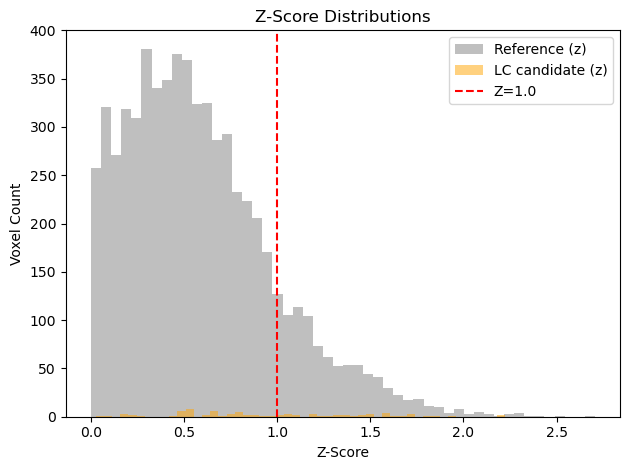

subject: sub-M3101
Mean z-score in LC: 0.54 ± 0.84
Max z in LC region: 2.2237594
Z-threshold: 1.0


In [ ]:
# # -------------
# Step3: Thresholding and identify LC regions
# # -------------

# --- Setup ---
sub_idx = 1  # choose subject index
sub_id = SUBJECT_ID[sub_idx]
subj_dir = DIR_3DCUBEFILES[sub_idx].parent

# --- Load files as ANTs images ---
pd_cube_native = ants.image_read(str(subj_dir / f"{sub_id}_PDcube_native.nii.gz"))
lc_mask_native = ants.image_read(str(subj_dir / f"{sub_id}_LC_mask_native.nii.gz"))
ref_mask_native = ants.image_read(str(subj_dir / f"{sub_id}_Ref_mask_native.nii.gz"))

# --- Get data as arrays ---
pd_data_native = pd_cube_native.numpy()
ref_mask_arr = ref_mask_native.numpy()
lc_mask_arr = lc_mask_native.numpy()

# --- Remove LC region from reference ---
# ref_mask_cleaned_arr = np.where(lc_mask_arr > 0, 0, ref_mask_arr)
ref_mask_cleaned_arr = np.where((lc_mask_arr > 0) | (pd_data_native <= 0), 0, ref_mask_arr) # exlude mismatched background


# --- Compute baseline intensity from reference region ---
ref_vals = pd_data_native[ref_mask_cleaned_arr > 0]
ref_mean = np.mean(ref_vals)
ref_std = np.std(ref_vals)

# --- Compute full z-score map ---
z_map = (pd_data_native - ref_mean) / ref_std

# --- Extract z-scores for LC mask ---
lc_voxel_indices = np.where(lc_mask_arr > 0)
z_scored = z_map[lc_voxel_indices]

# --- Threshold LC voxels by z-score ---
z_threshold = 1.0  # change if needed
lc_defined_arr = np.zeros_like(lc_mask_arr, dtype=np.uint8)
lc_defined_arr[lc_voxel_indices] = (z_scored > z_threshold).astype(np.uint8)

# --- Save identified LC mask as ANTs image ---
lc_defined_native = ants.from_numpy(
    lc_defined_arr,
    origin=lc_mask_native.origin,
    spacing=lc_mask_native.spacing,
    direction=lc_mask_native.direction
)

out_path = subj_dir / f"{sub_id}_LCDefined_mask_native.nii.gz"
ants.image_write(lc_defined_native, str(out_path))
print(f"Saved: {out_path}")

# --- Plot z-score distributions ---
z_ref_vals = z_map[(ref_mask_cleaned_arr > 0) & (z_map > 0)]
z_lc_vals  = z_map[(lc_mask_arr > 0) & (z_map > 0)]

plt.hist(z_ref_vals, bins=50, alpha=0.5, label='Reference (z)', color='gray')
plt.hist(z_lc_vals, bins=50, alpha=0.5, label='LC candidate (z)', color='orange')
plt.axvline(z_threshold, color='red', linestyle='--', label=f'Z={z_threshold}')
plt.xlabel("Z-Score")
plt.ylabel("Voxel Count")
plt.title("Z-Score Distributions")
plt.legend()
plt.tight_layout()
plt.show()

# --- Summary ---
print('subject:',sub_id)
print(f"Mean z-score in LC: {np.mean(z_scored):.2f} ± {np.std(z_scored):.2f}")
print("Max z in LC region:", np.max(z_scored))
print("Z-threshold:", z_threshold)

In [ ]:
# # -------------
# Checking: oberlays of lc mask and identified region
# # ------------

# --- Convert ANTs images to Nibabel format ---
ref_mask_cleaned = ants.from_numpy(
    ref_mask_cleaned_arr,
    origin=ref_mask_native.origin,
    spacing=ref_mask_native.spacing,
    direction=ref_mask_native.direction
)

ref_mask_nib = ants_to_nib(ref_mask_cleaned)
lc_defined_nib = ants_to_nib(lc_defined_native)

# --- Plot (no .show() needed) ---
display = plotting.plot_stat_map(
    stat_map_img=lc_defined_nib,
    bg_img=ref_mask_nib,
    cmap='Reds',
    display_mode='ortho',
    threshold=0.01,
    black_bg=True,
    draw_cross=True,
    title="LC Mask over Cleaned Reference"
)

In [104]:
# # -------------
# Checking: identified LC regions
# # -------------

pd_nib = ants_to_nib(pd_cube_native)
lc_mask_nib = ants_to_nib(lc_mask_native)
lc_defined_nib = ants_to_nib(lc_defined_native)

# Scale intensity of PD 
pd_arr = pd_nib.get_fdata()
pd_scaled = (pd_arr - pd_arr.min()) / (pd_arr.max() - pd_arr.min())
pd_scaled_img = nib.Nifti1Image(pd_scaled, affine=pd_nib.affine)

# --- Visualize interactively ---
# Show LC-defined mask over PD, with LC mask as overlay
viewer = plotting.view_img(
    stat_map_img=lc_defined_nib,        # Thresholded LC voxels
    bg_img=pd_scaled_img,                      # Background PD image
    cmap='autumn',
    threshold=0.01,
    title="LC Voxels > 2.5 SD over Pons (Native Space)"
)

viewer.open_in_browser()

/Users/atsushikikumoto/opt/anaconda3/envs/mri/lib/python3.10/site-packages/numpy/core/fromnumeric.py:771: UserWarning:


/var/folders/st/vdmcwrln1mb0m0p2cbhwfhvc0000gn/T/ipykernel_36524/2801596098.py:16: UserWarning:

Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.



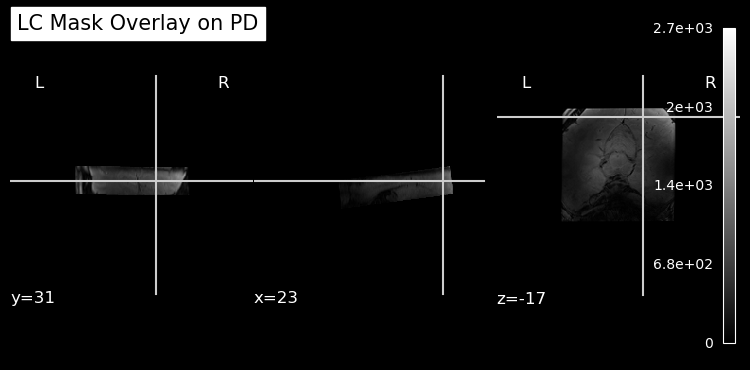

In [87]:
# # -------------
# Checking: oberlays of lc mask and identified region
# # ------------
display = plotting.plot_anat(pd_nib, title='LC Mask Overlay on PD', display_mode='ortho')
display.add_overlay(lc_mask_nib, cmap='Blues', vmin=0.5, vmax=1.0)
display.add_overlay(lc_defined_nib, cmap='autumn', vmin=0.5, vmax=1.0)


In [ ]:
# # -------------
# Prepare summarized outputs for TUS (bilaterally)
# # -------------
import ants
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.ndimage import binary_erosion

# --- Threshold and extract coords from initial binary mask ---
# Define target
sub_idx = 0
target_label = "LCDefined"  # 
sub_id = DIR_T1FILES[sub_idx].stem.split("_")[0]
subject_dir = DIR_T1FILES[sub_idx].parent

# Load and save t1 as RAS orientation for neuronavigation
t1_native = ants.image_read(str(DIR_T1FILES[sub_idx]))
t1_native_ras = ants.reorient_image2(t1_native, orientation='RAS')
# output_path = DIR_T1FILES[sub_idx].parent / f"{sub_id}_{target_label}_native_overlay.png"
# ants.image_write(t1_native_ras, str(subject_dir / f"{sub_id}_T1w_RAS.nii.gz"))

# Load pre-warped native-space mask (already thresholded & in native orientation)
mask_native_path = DIR_T1FILES[sub_idx].parent / f"{sub_id}_{target_label}_mask_native.nii.gz"
mask_native = ants.image_read(str(mask_native_path))
# mask_native_ras = ants.reorient_image2(mask_native, orientation='RAS')

threshold = 0.0
mask_thresh = mask_native > threshold
mask_np = mask_thresh.numpy()

direction = np.array(mask_thresh.direction)
spacing = np.array(mask_thresh.spacing)
origin = np.array(mask_thresh.origin)

affine = np.eye(4)
affine[:3, :3] = direction * spacing
affine[:3, 3] = origin

i, j, k = np.nonzero(mask_np > 0)
coords_vox = np.c_[i, j, k]
coords_world = coords_vox @ affine[:3, :3].T + origin

# --- Split into hemispheres ---
left_idx = coords_world[:, 0] < 0
right_idx = coords_world[:, 0] > 0

# --- Load segmentation maps ---
c1 = ants.image_read(str(DIR_T1C1FILES[sub_idx]))  # GM
c2 = ants.image_read(str(DIR_T1C2FILES[sub_idx]))  # WM
c3 = ants.image_read(str(DIR_T1C3FILES[sub_idx]))  # CSF
c4 = ants.image_read(str(DIR_T1C4FILES[sub_idx]))  # ???
c5 = ants.image_read(str(DIR_T1C5FILES[sub_idx]))  # Scalp
c6 = ants.image_read(str(DIR_T1C6FILES[sub_idx]))  # Background

# --- Dilate scalp to include near-surface tissues ---
c5_dilated = ants.morphology(c5, operation='dilate', radius=2)

# --- Subtract binarized background ---
c6_bin = (c6.numpy() > 0.1).astype(np.uint8)  # More conservative subtraction

# --- Combine tissues and subtract background ---
combined_np = (
    c1.numpy() + c2.numpy() + c3.numpy() + c4.numpy() + c5_dilated.numpy()
)
combined_cleaned = combined_np * (1 - c6_bin)

# --- Smooth and binarize ---
smoothed_prob = gaussian_filter(combined_cleaned, sigma=1)
combined_mask = (smoothed_prob > 0.2).astype(np.uint8)

# --- Optional: restrict to surface shell ---
eroded = binary_erosion(combined_mask, iterations=2)
surface_mask = combined_mask.copy()
surface_mask[eroded > 0] = 0

# --- Affine (reuse from above) ---
affine = np.eye(4)
affine[:3, :3] = direction * spacing
affine[:3, 3] = origin

# --- Convert to world coordinates ---
surface_i, surface_j, surface_k = np.nonzero(surface_mask)
surface_vox = np.c_[surface_i, surface_j, surface_k]
surface_world = surface_vox @ affine[:3, :3].T + origin

# --- Ready for analysis ---
rows = []

for hemi_label, hemi_idx in zip(["R", "L"], [left_idx, right_idx]):
    if hemi_idx.sum() == 0:
        continue

    # Hemisphere mask
    hemi_mask = np.zeros_like(mask_np)
    hemi_mask[i[hemi_idx], j[hemi_idx], k[hemi_idx]] = 1
    hemi_mask_ants = ants.from_numpy(
        hemi_mask,
        origin=tuple(origin),
        spacing=tuple(spacing),
        direction=tuple(direction)
    )

    # Center of mass
    label_image = hemi_mask_ants * 1
    stats = ants.label_stats(hemi_mask_ants, label_image)
    stats_label_1 = stats[stats['LabelValue'] == 1.0]
    com_xyz = np.array([
        stats_label_1['x'].values[0],
        stats_label_1['y'].values[0],
        stats_label_1['z'].values[0]
    ])

    # --- Optional: restrict surface points to superior skull only ---
    keep_idx = surface_world[:, 2] > (com_xyz[2] - 10)
    filtered_surface = surface_world[keep_idx]

    # --- Compute minimum distance ---
    dists = cdist([com_xyz], filtered_surface)
    min_dist = float(np.min(dists))
    closest_point = filtered_surface[np.argmin(dists)]

    # Orientation matrix
    m = affine[:3, :3]

    # Save
    rows.append({
        'subject_id': sub_id,
        'hemisphere': hemi_label,
        'mask_used': mask_native_path.name,
        'x': com_xyz[0],
        'y': com_xyz[1],
        'z': com_xyz[2],
        #'distance_to_scalp': round(min_dist, 2),
        #'x_closest_scalp': closest_point[0],
        #'y_closest_scalp': closest_point[1],
        #'z_closest_scalp': closest_point[2],
        'count': stats_label_1['Count'].values[0],
        'volume': stats_label_1['Volume'].values[0],
        'mass': stats_label_1['Mass'].values[0],
        't1_path': str(DIR_T1FILES[sub_idx]),
        "m0n0": m[0, 0], "m0n1": m[0, 1], "m0n2": m[0, 2],
        "m1n0": m[1, 0], "m1n1": m[1, 1], "m1n2": m[1, 2],
        "m2n0": m[2, 0], "m2n1": m[2, 1], "m2n2": m[2, 2]
    })

# --- Save full detailed CSV ---
df_out = pd.DataFrame(rows)
csv_filename = f"{sub_id}_{target_label}_target_coordinates_native.csv"
csv_path = subject_dir / csv_filename

# --- Save Brainsight-compatible TXT (tab-delimited, flipped X/Y coords + orientation) ---
brainsight_header = [
    "# Version: 13",
    "# Coordinate system: NIfTI:Scanner",
    "# Created by: Brainsight 2.5.1",
    "# Units: millimetres, degrees, milliseconds, and microvolts",
    "# Encoding: UTF-8",
    "# Notes: Each column is delimited by a tab. Each value within a column is delimited by a semicolon.",
    "# Target Name\tLoc. X\tLoc. Y\tLoc. Z\tm0n0\tm0n1\tm0n2\tm1n0\tm1n1\tm1n2\tm2n0\tm2n1\tm2n2"
]

rows_bs = []

for _, row in df_out.iterrows():
    hemi = row['hemisphere']
    label = f"{target_label}_{hemi}"

    # Orientation matrix in native space
    m_native = np.array([
        [row["m0n0"], row["m0n1"], row["m0n2"]],
        [row["m1n0"], row["m1n1"], row["m1n2"]],
        [row["m2n0"], row["m2n1"], row["m2n2"]],
    ])
    m_flipped = np.diag([-1, -1, 1]) @ m_native  # RAS to LAS

    # --- Add Target Point ---
    rows_bs.append({
        "Target Name": f"{label}_Target",
        "Loc. X": round(-row["x"], 4),
        "Loc. Y": round(-row["y"], 4),
        "Loc. Z": round(row["z"], 4),
        "m0n0": round(m_flipped[0, 0], 6), "m0n1": round(m_flipped[0, 1], 6), "m0n2": round(m_flipped[0, 2], 6),
        "m1n0": round(m_flipped[1, 0], 6), "m1n1": round(m_flipped[1, 1], 6), "m1n2": round(m_flipped[1, 2], 6),
        "m2n0": round(m_flipped[2, 0], 6), "m2n1": round(m_flipped[2, 1], 6), "m2n2": round(m_flipped[2, 2], 6),
    })

    # --- Add Closest Scalp Point ---
    #rows_bs.append({
    #    "Target Name": f"{label}_Scalp",
    #    "Loc. X": round(-row["x_closest_scalp"], 4),
    #    "Loc. Y": round(-row["y_closest_scalp"], 4),
    #    "Loc. Z": round(row["z_closest_scalp"], 4),
    #    "m0n0": round(m_flipped[0, 0], 6), "m0n1": round(m_flipped[0, 1], 6), "m0n2": round(m_flipped[0, 2], 6),
    #    "m1n0": round(m_flipped[1, 0], 6), "m1n1": round(m_flipped[1, 1], 6), "m1n2": round(m_flipped[1, 2], 6),
    #    "m2n0": round(m_flipped[2, 0], 6), "m2n1": round(m_flipped[2, 1], 6), "m2n2": round(m_flipped[2, 2], 6),
    #})

# Save TXT
df_brainsight = pd.DataFrame(rows_bs)
bs_filename = f"{sub_id}_{target_label}_target_coordinates_BrainsightTargets.txt"
bs_path = subject_dir / bs_filename
with open(bs_path, "w", encoding="utf-8") as f:
    for line in brainsight_header:
        f.write(line + "\n")
    df_brainsight.to_csv(f, sep="\t", index=False, header=False)

# --- Preview
df_out


In [ ]:
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# ------------- OLDER SCRIPTS (DONT USE) ----------------------
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [ ]:
# # -------------
# Inverse registration (MNI -> native)
# register MNI T1 template to subject-specific T1 data
# save transformation and apply to LC map
# -in ANTs, fwdtransforms actually maps moving → fixed 
# # -------------

# Estimate transformation using native T1 and MNI T1 (MNI -> native)
t1_7t_native = load_as_3d(DIR_T1FILES[0])

reg_sub_mni = ants.registration(
    fixed=t1_7t_native, 
    moving=t1_mni, 
    type_of_transform='SyN')


# Apply same transformation to LC map (MNI -> native)
# lc_mni = ants.image_read("LC_mask_Dahl2022.nii.gz")  # once you have it

# lc_native = ants.apply_transforms(
#     fixed=t1_7t_native, 
#     moving=lc_mni, 
#     transformlist=reg_sub_mni['fwdtransforms'],  # use forward transform
#     interpolator='nearestNeighbor'  # for binary or probabilistic mask
# )

# ants.image_write(lc_native, "LC_mask_native.nii.gz")

In [39]:
# # -------------
# Checking header information
# # -------------
import nibabel as nib
idx = 0
img = nib.load(str(DIR_T1FILES[idx])) # change file path here
print("Shape:", img.shape)
print("Voxel size (zooms):", img.header.get_zooms())
print("Data type:", img.get_data_dtype())
print("Affine matrix:\n", img.affine)

Shape: (256, 256, 256, 2)
Voxel size (zooms): (0.8008, 0.8008, 0.8, 3.24256)
Data type: float32
Affine matrix:
 [[ 4.46846383e-03  0.00000000e+00  7.99983978e-01 -9.43706665e+01]
 [-8.00783992e-01  0.00000000e+00  4.46400000e-03  1.26842468e+02]
 [ 0.00000000e+00 -8.00800025e-01  0.00000000e+00  9.44366074e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [33]:
# # -------------
# Within-sub registration (native -> native)
# base approach
# # -------------

# Load and reorient to RAS
idx = 1
t1_7t_native = reorient_to_ras(load_as_3d(DIR_T1FILES[idx]))
cube_native = reorient_to_ras(load_as_3d(DIR_3DCUBEFILES[idx]))

# Flip Y (axis=1 = anterior-posterior)
cube_native = ants.from_numpy(
    np.flip(cube_native.numpy(), axis=1),
    origin=cube_native.origin,
    spacing=cube_native.spacing,
    direction=cube_native.direction
)

# Match origin/direction to T1
# cube_native.set_origin(t1_7t_native.origin)
# cube_native.set_direction(t1_7t_native.direction)

# Affine registration
reg_cube_to_t1 = ants.registration(
    fixed=t1_7t_native,
    moving=cube_native,
    type_of_transform="Affine"
)

# Step 4: Save result
pd_cube_aligned = reg_cube_to_t1["warpedmovout"]
output_path = DIR_3DCUBEFILES[idx].parent / f"{SUBJECT_ID[idx]}_PDcube_aligned_to_T1.nii.gz"
ants.image_write(pd_cube_aligned, str(output_path))

In [36]:
# Load and reorient to RAS
idx = 0
t1_7t_native = reorient_to_ras(load_as_3d(DIR_T1FILES[idx]))
cube_native = reorient_to_ras(load_as_3d(DIR_3DCUBEFILES[idx]))

# Flip Y axis (axis=1 = anterior–posterior)
cube_native = ants.from_numpy(
    np.flip(cube_native.numpy(), axis=1),
    origin=cube_native.origin,
    spacing=cube_native.spacing,
    direction=cube_native.direction
)

# Match origin and direction to T1
cube_native.set_origin(t1_7t_native.origin)
cube_native.set_direction(t1_7t_native.direction)

# Apply manual posterior shift (~15 mm)
manual_shift = ants.create_ants_transform(
    transform_type='Euler3DTransform',
    center=t1_7t_native.get_center_of_mass(),
    translation=(0, -25, -20)  # Y = posterior, Z = inferior
)

cube_native_shifted = ants.apply_ants_transform_to_image(
    transform=manual_shift,
    image=cube_native,
    reference=t1_7t_native
)

# Affine registration (with shifted image)
reg_cube_to_t1 = ants.registration(
    fixed=t1_7t_native,
    moving=cube_native_shifted,
    type_of_transform="Affine"
)

# Save output
pd_cube_aligned = reg_cube_to_t1["warpedmovout"]
output_path = DIR_3DCUBEFILES[idx].parent / f"{SUBJECT_ID[idx]}_PDcube_aligned_to_T1.nii.gz"
ants.image_write(pd_cube_aligned, str(output_path))

Converting 4D image to 3D: sub-F2003_T1w_7T.nii with shape (256, 256, 256, 2)
 → Averaging 2 volumes


In [ ]:
# # # -------------
# # Within-sub registration (native -> native)
# # 
# # # -------------
# import tempfile
# # Load subject's 3D-CUBE PD image (native space)
# idx = 0
# t1_7t_native = reorient_to_ras(load_as_3d(DIR_T1FILES[idx]))
# cube_native = reorient_to_ras(load_as_3d(DIR_3DCUBEFILES[idx]))

# # Flip Y (anterior–posterior) and set origin/direction/spacing
# cube_native = ants.from_numpy(
#     np.flip(cube_native.numpy(), axis=1),  # axis=1 = Y
#     origin=t1_7t_native.origin,            # match T1 origin *here*
#     spacing=cube_native.spacing,
#     direction=cube_native.direction
# )

# # Define initial manual shift (e.g., ~15 mm posterior)
# init_tx = ants.create_ants_transform(
#     transform_type='Euler3DTransform',
#     center=t1_7t_native.get_center_of_mass(),
#     translation=(0, -15, 0)
# )

# with tempfile.NamedTemporaryFile(suffix='.mat', delete=False) as tf:
#     init_tx_file = tf.name
# ants.write_transform(init_tx, init_tx_file)

# # Register 3D-CUBE PD image to native T1 (affine preferred)
# reg_cube_to_t1 = ants.registration(
#     fixed=t1_7t_native,
#     moving=cube_native,
#     type_of_transform="Affine",
#     initial_transform=[init_tx_file]
# )

# # Get aligned output
# pd_cube_aligned = reg_cube_to_t1["warpedmovout"]

# # Save output
# output_path = DIR_3DCUBEFILES[idx].parent / f"{SUBJECT_ID[idx]}_PDcube_aligned_to_T1.nii.gz"
# ants.image_write(pd_cube_aligned, str(output_path))


Converting 4D image to 3D: sub-F2003_T1w_7T.nii with shape (256, 256, 256, 2)
 → Averaging 2 volumes


In [3]:
print("T1 origin:", t1_7t_native.origin)
print("CUBE origin:", cube_native.origin)
print("CUBE native direction:\n", cube_native.direction)
print("T1 direction:\n", t1_7t_native.direction)
print("CUBE direction:\n", cube_native.direction)

T1 origin: (93.231201171875, 77.35836029052734, -109.76740264892578)
CUBE origin: (93.231201171875, 77.35836029052734, -109.76740264892578)
CUBE native direction:
 [[-9.99999999e-01  1.81315811e-05 -4.72812069e-05]
 [-1.76690582e-06 -9.45624127e-01 -3.25261448e-01]
 [-5.06077558e-05 -3.25261449e-01  9.45624126e-01]]
T1 direction:
 [[-0.99998443  0.00558002  0.        ]
 [-0.00558002 -0.99998443  0.        ]
 [ 0.          0.          1.        ]]
CUBE direction:
 [[-9.99999999e-01  1.81315811e-05 -4.72812069e-05]
 [-1.76690582e-06 -9.45624127e-01 -3.25261448e-01]
 [-5.06077558e-05 -3.25261449e-01  9.45624126e-01]]


/Users/atsushikikumoto/opt/anaconda3/envs/mri/lib/python3.10/site-packages/numpy/core/fromnumeric.py:771: UserWarning:


/Users/atsushikikumoto/opt/anaconda3/envs/mri/lib/python3.10/site-packages/nilearn/plotting/html_document.py:102: UserWarning:

It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.




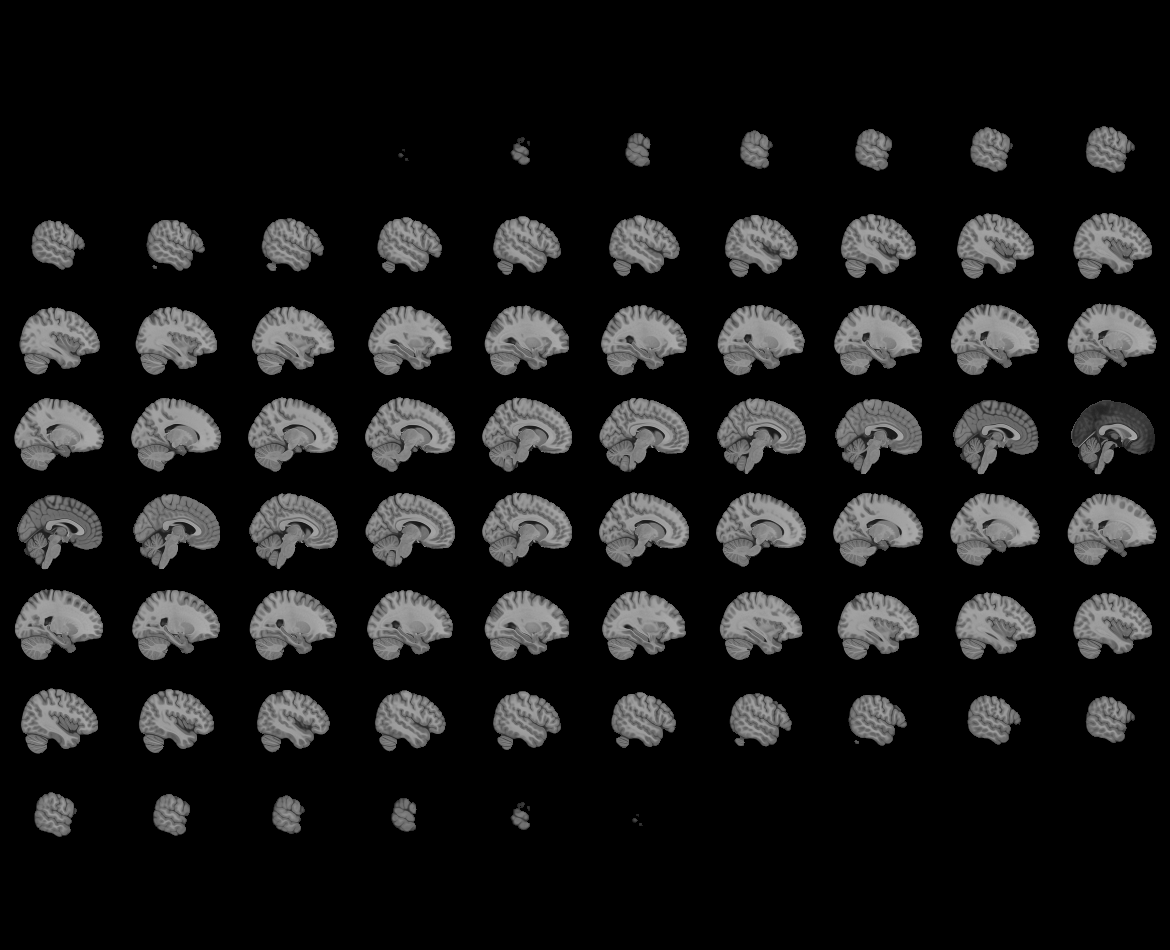
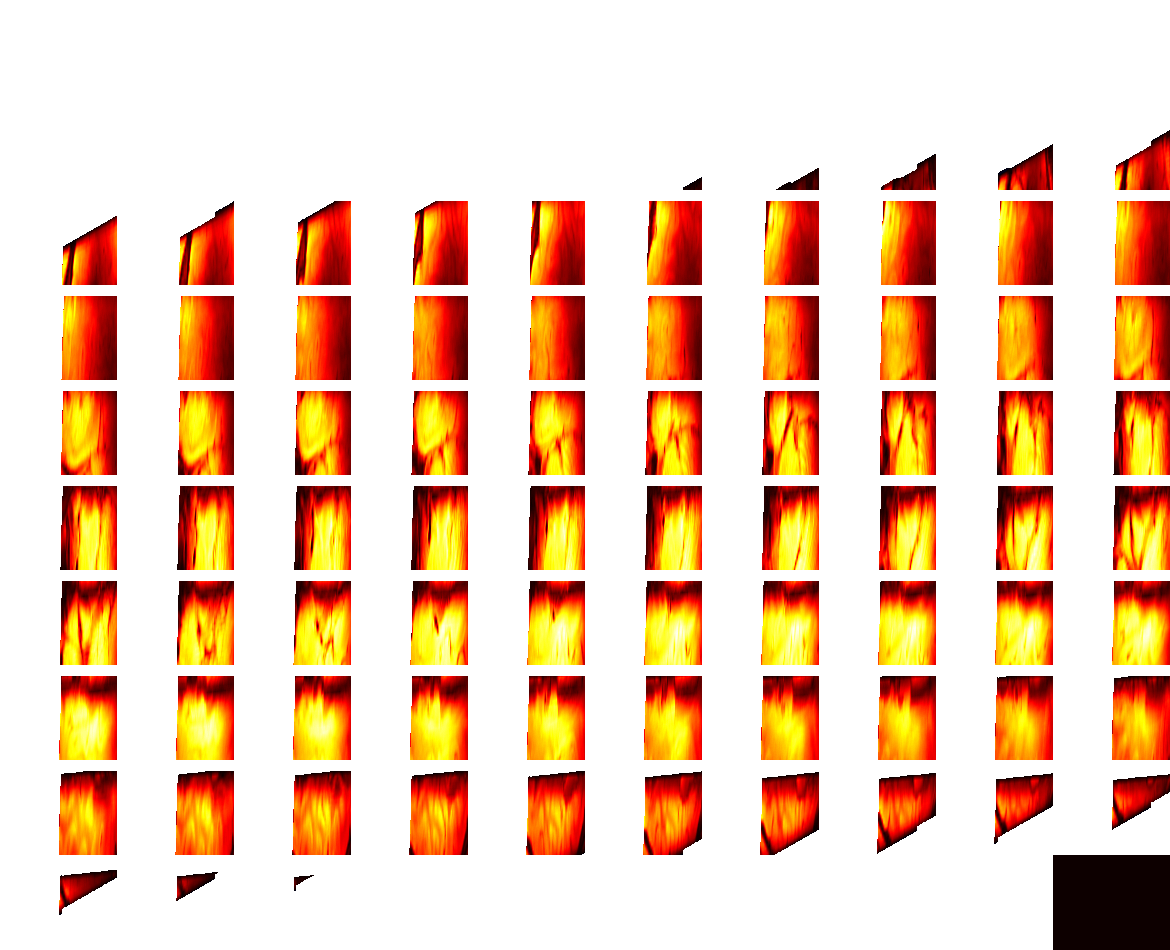

In [37]:

# Checking
from nilearn import plotting

# Interactive HTML viewer (works inside VS Code notebooks)
plotting.view_img(str(DIR_3DCUBEFILES[idx].parent / f"{SUBJECT_ID[idx]}_PDcube_aligned_to_T1.nii.gz"))


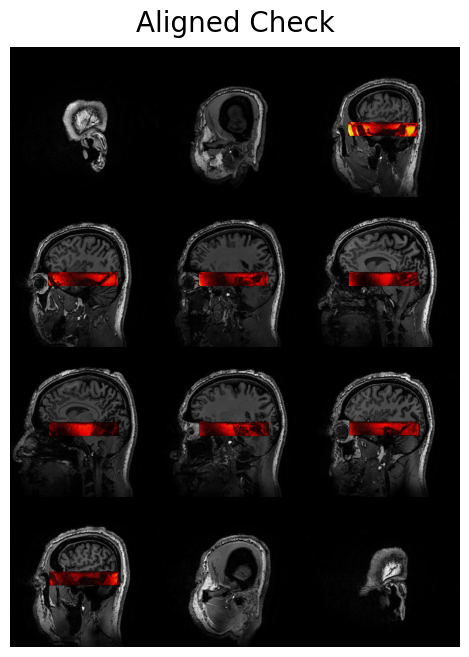

In [32]:
# Checking2
ants.plot(t1_7t_native, overlay=pd_cube_aligned, overlay_cmap='hot', title='Aligned Check')


In [32]:
# # -------------
# # Register T1 to MNI space using ANTsPy
# # -------------
DIR_T1FILES

[PosixPath('/Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/163655E819_230310F2003.Shibata_CUBE_250623/sub-F2003_T1w_7T.nii'),
 PosixPath('/Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/120921E825_200604M3101.Shibata_CUBE_250623/sub-M3101_T1w_7T.nii'),
 PosixPath('/Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/161324E837_200326M3902.Shibata_CUBE_250623/sub-M3902_T1w_7T.nii'),
 PosixPath('/Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/163938E828_021004M2401.Shibata_CUBE_250623/sub-M2401_T1w_7T.nii')]

In [ ]:
# # -------------
# # Re-orientation
# # -------------
# Original: ('P', 'I', 'L')
# - X axis: Posterior → Anterior (but reversed, so Anterior → Posterior; i.e., R is negative X)
# - Y axis: Inferior → Superior (but reversed, so Superior → Inferior)
# - Z axis: Left → Right (but reversed, so Right → Left)
# Transformed : ('R', 'A', 'S')
# - X axis: Right → Left (positive X = Right)
# - Y axis: Anterior → Posterior (positive Y = Anterior)
# - Z axis: Superior → Inferior (positive Z = Superior)

# Load reference nii data 
ref_img = nib.load(str(DIR_T1FILES[0]))
ref_affine = ref_img.affine

# Get orientation transform to RAS+
current_ornt = io_orientation(ref_affine)
target_ornt = axcodes2ornt(('R', 'A', 'S'))
xform = ornt_transform(current_ornt, target_ornt)

# Apply orientation to the NumPy label map
# [[1. 0. 0. 0.]   # X: increases along +i (right)
#  [0. 1. 0. 0.]   # Y: increases along +j (anterior)
#  [0. 0. 1. 0.]   # Z: increases along +k (superior)
#  [0. 0. 0. 1.]]
label_map_ras = apply_orientation(label_map, xform)
affine_ras = np.eye(4)


In [ ]:
# # -------------
# # Interactive plot (test)
# # -------------
# import ipywidgets as widgets
# from IPython.display import display

# slider = widgets.IntSlider(description='Test slider')
# display(slider)


# -------------
# Interactive plot
# -------------
# Set your volume here
matrix_3d = label_map_ras  # or clean_brain, etc.

# --- Slice Viewer ---
def update_plot(view_direction, slice_index):
    plt.figure(figsize=(6, 6))
    
    if view_direction == 'Axial':       # Z axis (top-down)
        plt.imshow(np.rot90(matrix_3d[:, :, slice_index]), cmap='gray')
        plt.title(f'Axial (Z) Slice {slice_index}')
        plt.xlabel('X (R→L)')
        plt.ylabel('Y (A→P)')
        
    elif view_direction == 'Sagittal':  # X axis (side view)
        plt.imshow(np.rot90(matrix_3d[slice_index, :, :]), cmap='gray')
        plt.title(f'Sagittal (X) Slice {slice_index}')
        plt.xlabel('Y (A→P)')
        plt.ylabel('Z (S→I)')
        
    elif view_direction == 'Coronal':   # Y axis (front view)
        plt.imshow(np.rot90(matrix_3d[:, slice_index, :]), cmap='gray')
        plt.title(f'Coronal (Y) Slice {slice_index}')
        plt.xlabel('X (R→L)')
        plt.ylabel('Z (S→I)')

    plt.colorbar()
    plt.tight_layout()
    plt.show()

# Interactive controls
view_direction_slider = widgets.Dropdown(
    options=['Axial', 'Sagittal', 'Coronal'],
    value='Axial',
    description='View:'
)

slice_slider = widgets.IntSlider(
    value=matrix_3d.shape[2] // 2,
    min=0,
    max=matrix_3d.shape[2] - 1,
    description='Slice:'
)

# Adjust max slice depending on view
def update_slice_range(view_direction):
    if view_direction == 'Axial':
        slice_slider.max = matrix_3d.shape[2] - 1
        slice_slider.value = matrix_3d.shape[2] // 2
    elif view_direction == 'Sagittal':
        slice_slider.max = matrix_3d.shape[0] - 1
        slice_slider.value = matrix_3d.shape[0] // 2
    elif view_direction == 'Coronal':
        slice_slider.max = matrix_3d.shape[1] - 1
        slice_slider.value = matrix_3d.shape[1] // 2

widgets.interact(update_slice_range, view_direction=view_direction_slider)

# Main interactive plot
interactive_plot = widgets.interactive(update_plot, view_direction=view_direction_slider, slice_index=slice_slider)
display(interactive_plot)

interactive(children=(Dropdown(description='View:', options=('Axial', 'Sagittal', 'Coronal'), value='Axial'), …

interactive(children=(Dropdown(description='View:', options=('Axial', 'Sagittal', 'Coronal'), value='Axial'), …

In [ ]:
# Apply slice-wise on the sagittal axis (or any axis)
threshold_area = 20
label_map_ras_clean = np.zeros_like(label_map_ras)

for i in range(label_map_ras.shape[0]):  # Iterate over sagittal slices (X-axis)
    label_map_ras_clean[i, :, :] = remove_small_clusters(label_map_ras[i, :, :], threshold_area=threshold_area)
    
# Plot original image
z = 120
plotImage(label_map_ras[:, :, z], title=f'Original Slice {z}')
plotImage(label_map_ras_clean[:, :, z], title=f'Cleaned Slice {z}')
removed = (label_map_ras - label_map_ras_clean).clip(min=0)
plotImage(removed[:, :, z], title=f'Removed Voxels (Original - Cleaned) at Slice {z}')

In [ ]:
# -------------
# Output
# -------------
## Save as new NIfTI
label_img = nib.Nifti1Image(label_map_ras_clean,affine=affine_ras,header=header) # after re-orientation
nib.save(label_img, seg_dir / t1_file.with_name(t1_file.stem + '_seg_thresholded.nii'))
scipy.io.savemat(seg_dir / t1_file.with_name(t1_file.stem + '_seg_thresholded.mat'), {'label_map_ras_clean': label_map_ras_clean})

In [ ]:
# Checking

import nibabel as nib

fname = t1_file.with_name(t1_file.stem + '_seg_thresholded.nii')
img = nib.load(fname)
print(img.header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 192 256 256   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 1. 1. 1. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'Tissue class 5'
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 0.0
qoffset_x       : 0.0
qoffset_y       : 0.0
qoffset_z       : 0.0
srow_x          : [1. 0. 0. 0.]
srow_y    

('P', 'I', 'L')


In [ ]:
def plotImage(img, title='', scale=1.0):
    # If 3D volume, default to middle axial slice
    if img.ndim == 3:
        img = img[:, :, img.shape[2] // 2]
    
    # Flip up-down and transpose to match anatomical axial view
    img_display = np.flipud(img.T)
    
    row, col = img_display.shape
    d = [go.Heatmap(z=img_display, x=np.arange(col), y=np.arange(row))]
    height = 600 * scale
    width = height * (col / row)
    layout = go.Layout(
        title=title,
        autosize=True,
        width=width,
        height=height,
    )
    fig = go.Figure(data=d, layout=layout)
    iplot(fig, show_link=False)
    
    
plotImage(label_map[:,:,100])


In [ ]:
scipy.io.savemat

<function scipy.io.matlab._mio.savemat(file_name, mdict, appendmat=True, format='5', long_field_names=False, do_compression=False, oned_as='row')>

In [ ]:
# # -------------
# # Saving .mat as .nii/.nii.gz
# # -------------


# # 1. Load the .mat file
# mat = scipy.io.loadmat('your_file.mat')

# # 2. Extract the 3D data array
# # Replace 'your_varname' with the actual variable name in the .mat file
# data = mat['your_varname']  # e.g., data.shape == (x, y, z)

# # 3. Define affine (identity or use a real one if you have it)
# affine = np.eye(4)

# # 4. Create NIfTI image
# nii = nib.Nifti1Image(data.astype(np.float32), affine)

# # 5. Save the NIfTI file
# nib.save(nii, 'output.nii.gz')